In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns


2026-04-09 07:32:49.377892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775719969.602595      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775719969.665285      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775719970.189900      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775719970.189943      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775719970.189946      55 computation_placer.cc:177] computation placer alr

In [2]:
dataset_path = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
classes = ["benign", "malignant", "normal"]

In [3]:
image_paths = []
labels = []
for c in classes:
    folder = os.path.join(dataset_path, c)
    for file in os.listdir(folder):
        if "mask" not in file:
            image_paths.append(os.path.join(folder, file))
            labels.append(c)

df = pd.DataFrame({"filename": image_paths, "class": labels})
print("Total images:",len(image_paths))
df["class"].value_counts()

Total images: 780


class
benign       437
malignant    210
normal       133
Name: count, dtype: int64

In [4]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["class"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["class"], random_state=42)


In [5]:
train_df, temp_df = train_test_split(df,test_size=0.30,stratify=df["class"],random_state=42)
val_df, test_df = train_test_split(temp_df,test_size=0.50,stratify=temp_df["class"],random_state=42)

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_gen = ImageDataGenerator(rescale=1./255,rotation_range=20,zoom_range=0.2,         
                      width_shift_range=0.2,height_shift_range=0.2,horizontal_flip=True,
                      shear_range=0.2,brightness_range=[0.8, 1.2])
test_gen = ImageDataGenerator(rescale=1./255)

In [7]:
train_data = train_gen.flow_from_dataframe(train_df, x_col="filename", y_col="class",
             target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
             class_mode="categorical", shuffle=True)

val_data = test_gen.flow_from_dataframe(val_df, x_col="filename", y_col="class",
           target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
           class_mode="categorical", shuffle=False)
test_data = test_gen.flow_from_dataframe(test_df, x_col="filename", y_col="class",
            target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
            class_mode="categorical", shuffle=False)

Found 546 validated image filenames belonging to 3 classes.
Found 117 validated image filenames belonging to 3 classes.
Found 117 validated image filenames belonging to 3 classes.


In [8]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True
x = GlobalAveragePooling2D()(base_model.output)  # Better than Flatten
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(3, activation="softmax")(x)

I0000 00:00:1775720002.215958      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4),loss="categorical_crossentropy",metrics=["accuracy"])

In [10]:
callbacks = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [11]:
history = model.fit(train_data,validation_data=val_data,epochs=50,callbacks=callbacks,verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1775720008.942457     124 service.cc:152] XLA service 0x7eff140120d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775720008.942506     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775720009.770045     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3438 - loss: 1.1799 

I0000 00:00:1775720017.205292     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 721ms/step - accuracy: 0.5281 - loss: 1.0467 - val_accuracy: 0.5556 - val_loss: 0.9129
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 399ms/step - accuracy: 0.5605 - loss: 0.9334 - val_accuracy: 0.6667 - val_loss: 0.7198
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 395ms/step - accuracy: 0.6518 - loss: 0.7565 - val_accuracy: 0.7692 - val_loss: 0.6099
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 388ms/step - accuracy: 0.6308 - loss: 0.7508 - val_accuracy: 0.7778 - val_loss: 0.6702
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 395ms/step - accuracy: 0.7145 - loss: 0.6599 - val_accuracy: 0.7265 - val_loss: 0.6692
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 391ms/step - accuracy: 0.7194 - loss: 0.6706 - val_accuracy: 0.7607 - val_loss: 0.5269
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 386ms/step - accuracy: 0.7056 - loss: 0.6351 - val_accuracy: 0.7949 - val_loss: 0.6342
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 384ms/step - accuracy: 0.7632 - loss: 0.5837 - val_accuracy: 0.820

In [12]:
pred = model.predict(test_data)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_data.classes
print(classification_report(true_classes, pred_classes))

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 315ms/step
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        66
           1       0.62      0.77      0.69        31
           2       0.77      0.85      0.81        20

    accuracy                           0.75       117
   macro avg       0.74      0.78      0.76       117
weighted avg       0.77      0.75      0.75       117



In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 30,057,803 (114.66 MB)

 Trainable params: 7,474,179 (28.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,948,360 (57.02 MB)

In [14]:
tf.keras.backend.clear_session()

In [15]:
from tensorflow.keras.layers import DepthwiseConv2D, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

def build_separable_vgg_logic(input_shape=(224, 224, 3), num_classes=3):
    inputs = Input(shape=input_shape)

   
    x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(inputs)
    x = Conv2D(64, kernel_size=(1, 1), activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
    x = Conv2D(128, kernel_size=(1, 1), activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
    x = Conv2D(256, kernel_size=(1, 1), activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = DepthwiseConv2D(kernel_size=(3, 3), padding='same', activation='relu')(x)
    x = Conv2D(512, kernel_size=(1, 1), activation='relu')(x)
    x = BatchNormalization()(x)
    
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    return Model(inputs=inputs, outputs=outputs)


model_dep = build_separable_vgg_logic()
model_dep.compile(optimizer=Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=["Accuracy"])

In [16]:
callbacks = EarlyStopping(monitor='val_loss', patience=10,restore_best_weights=True,verbose=1)

In [17]:
history_sep = model_dep.fit(train_data, validation_data=val_data, epochs=50, callbacks=callbacks)

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 827ms/step - Accuracy: 0.3976 - loss: 1.0776 - val_Accuracy: 0.5556 - val_loss: 1.0881
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 375ms/step - Accuracy: 0.5353 - loss: 1.0173 - val_Accuracy: 0.5556 - val_loss: 1.0806
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 377ms/step - Accuracy: 0.5599 - loss: 0.9971 - val_Accuracy: 0.5556 - val_loss: 1.0704
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 375ms/step - Accuracy: 0.5805 - loss: 0.9630 - val_Accuracy: 0.5556 - val_loss: 1.0623
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 378ms/step - Accuracy: 0.5483 - loss: 0.9830 - val_Accuracy: 0.5556 - val_loss: 1.0529
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 376ms/step - Accuracy: 0.5665 - loss: 0.9654 - val_Accuracy: 0.5556 - val_loss: 1.0454
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 370ms/step - Accuracy: 0.6094 - loss: 0.9271 - val_Accuracy: 0.5556 - val_loss: 1.0370
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 370ms/step - Accuracy: 0.5892 - loss: 0.9336 - val_Accu

In [18]:
pred = model_dep.predict(test_data)
pred_classes = np.argmax(pred, axis=1)
true_classes = test_data.classes
print(classification_report(true_classes, pred_classes))

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 369ms/step
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        66
           1       0.74      0.55      0.63        31
           2       0.71      0.50      0.59        20

    accuracy                           0.72       117
   macro avg       0.72      0.64      0.67       117
weighted avg       0.72      0.72      0.71       117



In [19]:
model_dep.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 224, 224, 3)    │            30 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 112, 112, 64)   │           640 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_2              │ (None, 56, 56, 128)    │         1,280 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 256)    │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_3              │ (None, 28, 28, 256)    │         2,560 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 512)    │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 937,061 (3.57 MB)

 Trainable params: 311,713 (1.19 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 623,428 (2.38 MB)

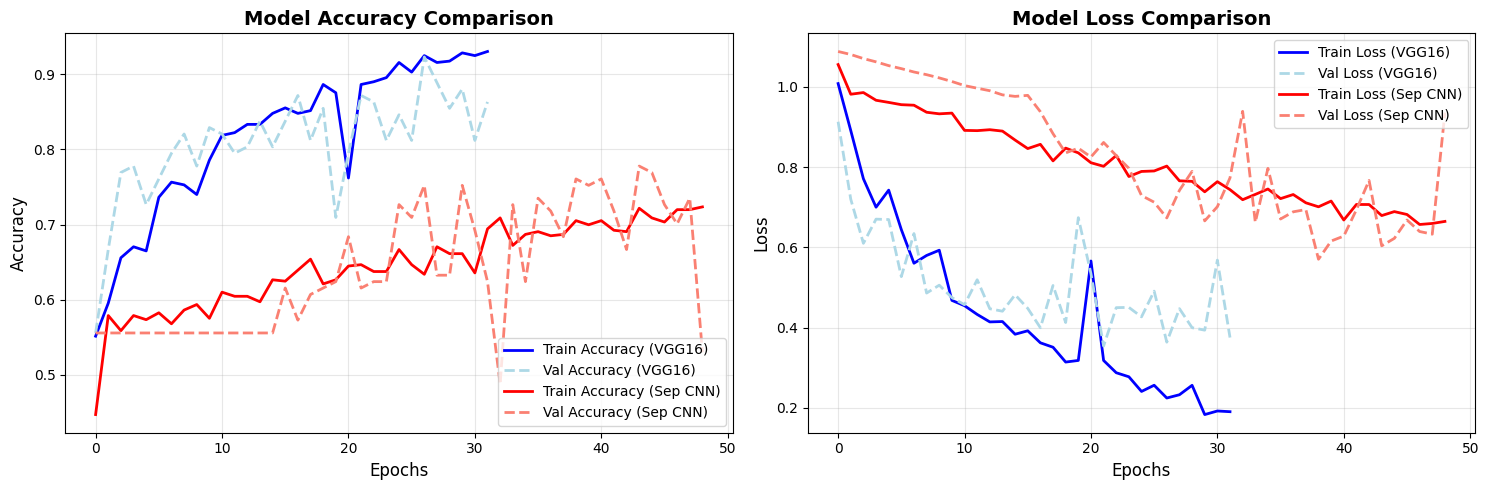

In [20]:
import matplotlib.pyplot as plt

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Training & Validation Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy (VGG16)', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy (VGG16)', color='lightblue', linestyle='--', linewidth=2)
axes[0].plot(history_sep.history['Accuracy'], label='Train Accuracy (Sep CNN)', color='red', linewidth=2)
axes[0].plot(history_sep.history['val_Accuracy'], label='Val Accuracy (Sep CNN)', color='salmon', linestyle='--', linewidth=2)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Plot Training & Validation Loss
axes[1].plot(history.history['loss'], label='Train Loss (VGG16)', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss (VGG16)', color='lightblue', linestyle='--', linewidth=2)
axes[1].plot(history_sep.history['loss'], label='Train Loss (Sep CNN)', color='red', linewidth=2)
axes[1].plot(history_sep.history['val_loss'], label='Val Loss (Sep CNN)', color='salmon', linestyle='--', linewidth=2)
axes[1].set_title('Model Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

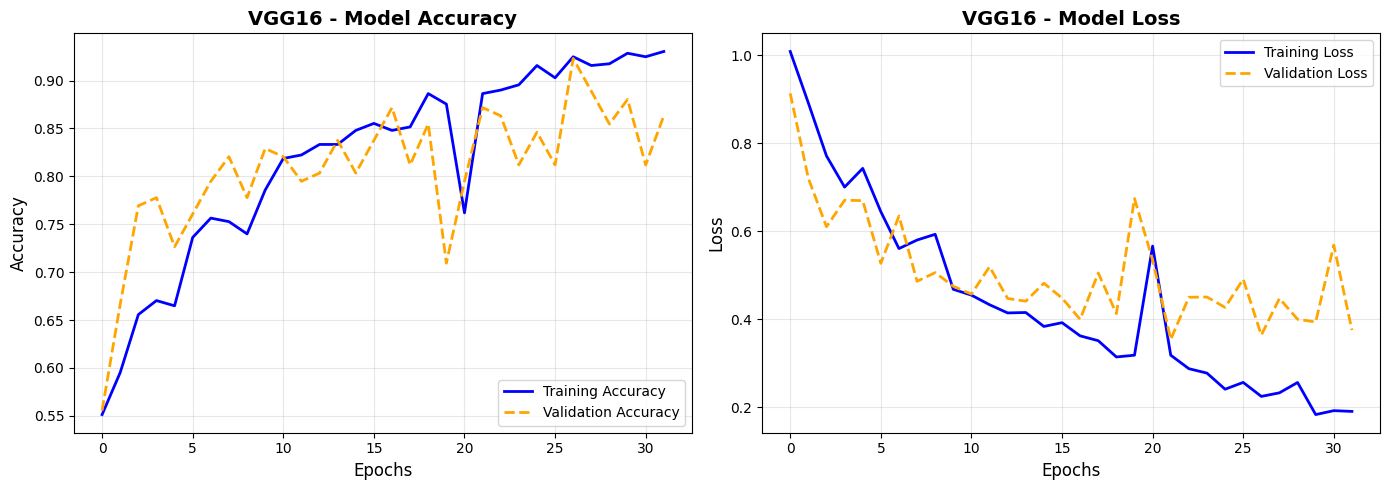

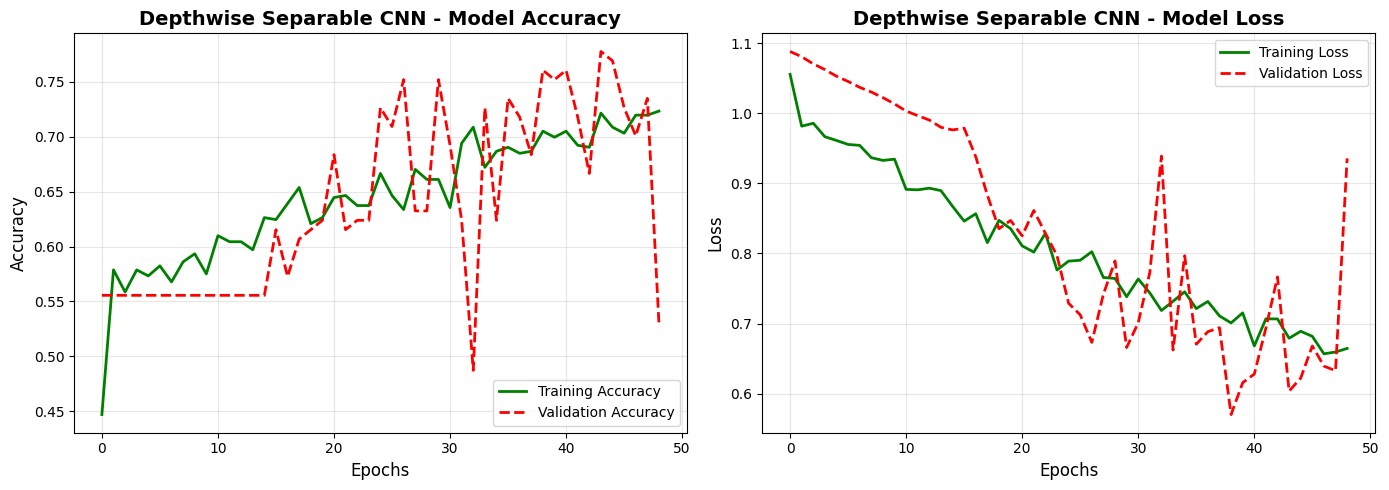

In [21]:
# Separate plots for VGG16
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VGG16 Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
axes[0].set_title('VGG16 - Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# VGG16 Loss
axes[1].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
axes[1].set_title('VGG16 - Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Separate plots for Depthwise Separable CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sep CNN Accuracy
axes[0].plot(history_sep.history['Accuracy'], label='Training Accuracy', color='green', linewidth=2)
axes[0].plot(history_sep.history['val_Accuracy'], label='Validation Accuracy', color='red', linestyle='--', linewidth=2)
axes[0].set_title('Depthwise Separable CNN - Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Sep CNN Loss
axes[1].plot(history_sep.history['loss'], label='Training Loss', color='green', linewidth=2)
axes[1].plot(history_sep.history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
axes[1].set_title('Depthwise Separable CNN - Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

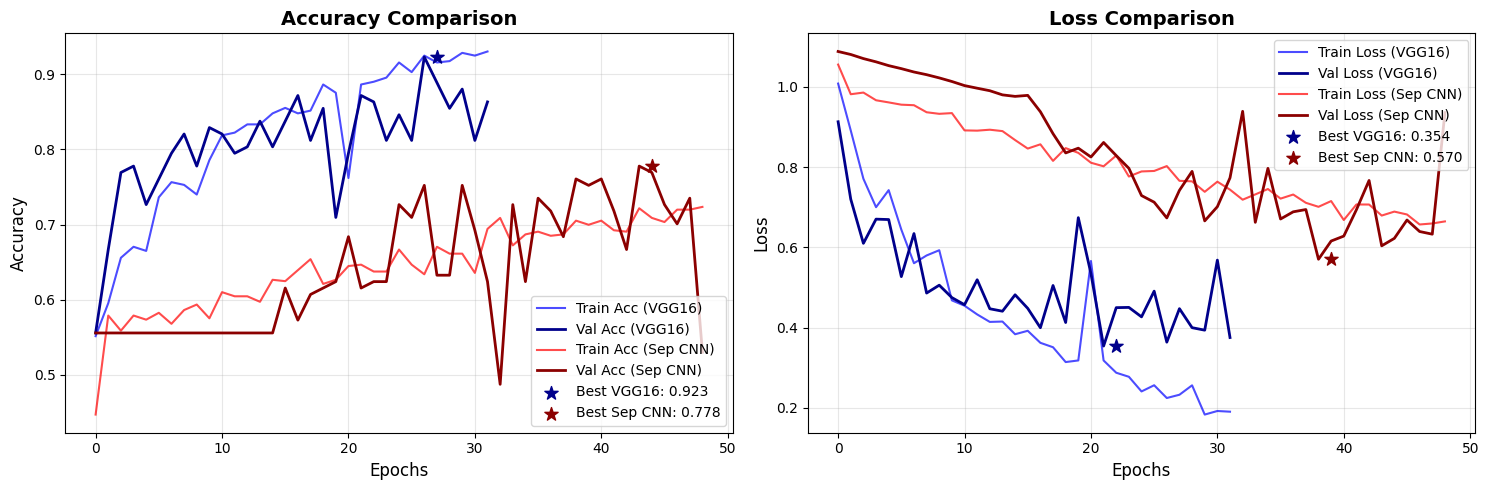

VGG16 - Best Validation Accuracy: 0.9231 at epoch 27
VGG16 - Best Validation Loss: 0.3538 at epoch 22
Sep CNN - Best Validation Accuracy: 0.7778 at epoch 44
Sep CNN - Best Validation Loss: 0.5702 at epoch 39


In [22]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Find best epochs
best_vgg_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
best_vgg_loss_epoch = np.argmin(history.history['val_loss']) + 1
best_sep_acc_epoch = np.argmax(history_sep.history['val_Accuracy']) + 1
best_sep_loss_epoch = np.argmin(history_sep.history['val_loss']) + 1

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Acc (VGG16)', color='blue', alpha=0.7)
axes[0].plot(history.history['val_accuracy'], label='Val Acc (VGG16)', color='darkblue', linewidth=2)
axes[0].plot(history_sep.history['Accuracy'], label='Train Acc (Sep CNN)', color='red', alpha=0.7)
axes[0].plot(history_sep.history['val_Accuracy'], label='Val Acc (Sep CNN)', color='darkred', linewidth=2)
axes[0].scatter(best_vgg_acc_epoch, max(history.history['val_accuracy']), 
                color='darkblue', s=100, marker='*', zorder=5, 
                label=f'Best VGG16: {max(history.history["val_accuracy"]):.3f}')
axes[0].scatter(best_sep_acc_epoch, max(history_sep.history['val_Accuracy']), 
                color='darkred', s=100, marker='*', zorder=5,
                label=f'Best Sep CNN: {max(history_sep.history["val_Accuracy"]):.3f}')
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss (VGG16)', color='blue', alpha=0.7)
axes[1].plot(history.history['val_loss'], label='Val Loss (VGG16)', color='darkblue', linewidth=2)
axes[1].plot(history_sep.history['loss'], label='Train Loss (Sep CNN)', color='red', alpha=0.7)
axes[1].plot(history_sep.history['val_loss'], label='Val Loss (Sep CNN)', color='darkred', linewidth=2)
axes[1].scatter(best_vgg_loss_epoch, min(history.history['val_loss']), 
                color='darkblue', s=100, marker='*', zorder=5,
                label=f'Best VGG16: {min(history.history["val_loss"]):.3f}')
axes[1].scatter(best_sep_loss_epoch, min(history_sep.history['val_loss']), 
                color='darkred', s=100, marker='*', zorder=5,
                label=f'Best Sep CNN: {min(history_sep.history["val_loss"]):.3f}')
axes[1].set_title('Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best epoch information
print(f"VGG16 - Best Validation Accuracy: {max(history.history['val_accuracy']):.4f} at epoch {best_vgg_acc_epoch}")
print(f"VGG16 - Best Validation Loss: {min(history.history['val_loss']):.4f} at epoch {best_vgg_loss_epoch}")
print(f"Sep CNN - Best Validation Accuracy: {max(history_sep.history['val_Accuracy']):.4f} at epoch {best_sep_acc_epoch}")
print(f"Sep CNN - Best Validation Loss: {min(history_sep.history['val_loss']):.4f} at epoch {best_sep_loss_epoch}")